In [1]:
!pip install transformers torch

Index(['ProductId', 'UserId', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
       'Score', 'clean_text', 'clean_summary', 'char_count', 'word_count',
       'avg_word_length', 'helpfulness_ratio', 'review_date', 'review_year',
       'review_month', 'review_day', 'sentiment', 'sentiment_label'],
      dtype='object')
    ProductId          UserId  HelpfulnessNumerator  HelpfulnessDenominator  \
0  B001E4KFG0  A3SGXH7AUHU8GW                   1.0                     1.0   
1  B00813GRG4  A1D87F6ZCVE5NK                   0.0                     0.0   
2  B000LQOCH0   ABXLMWJIXXAIN                   1.0                     1.0   
3  B000UA0QIQ  A395BORC6FGVXV                   3.0                     3.0   
4  B006K2ZZ7K  A1UQRSCLF8GW1T                   0.0                     0.0   

   Score                                         clean_text  \
0    5.0  i have bought several of the vitality canned d...   
1    1.0  product arrived labeled as jumbo salted peanut...   
2    4.0  th

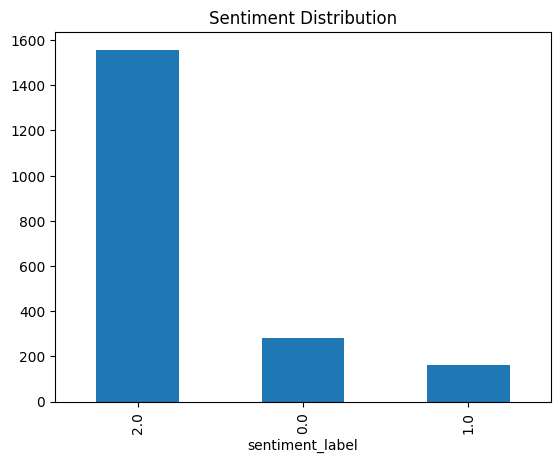

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("amazon.csv").head(2000)

# Check the data
print(df.columns)
print(df.head())

# Get sentiment counts
print("\nSentiment Distribution:")
print(df["sentiment_label"].value_counts())

# Get percentages
print("\nPercentages:")
print(df["sentiment_label"].value_counts(normalize=True) * 100)

# Make a bar chart
df["sentiment_label"].value_counts().plot(kind="bar", title="Sentiment Distribution")
plt.show()

In [6]:
sentiment_counts = df["sentiment_label"].value_counts(normalize=True) * 100
print("Sentiment Distribution (%)")
print(sentiment_counts)

Sentiment Distribution (%)
sentiment_label
2.0    77.90
0.0    14.05
1.0     8.05
Name: proportion, dtype: float64


In [7]:
print("\nSentiment vs Star Rating:")
print(pd.crosstab(df["Score"], df["sentiment_label"]))


Sentiment vs Star Rating:
sentiment_label  0.0  1.0   2.0
Score                          
1.0              178    0     0
2.0              103    0     0
3.0                0  161     0
4.0                0    0   255
5.0                0    0  1303


In [8]:
# Get only negative reviews
negative_reviews = df[df["sentiment_label"] == 0.0]["clean_text"]

# Get top words
from collections import Counter
words = []
for review in negative_reviews:
    words.extend(review.split())

top_words = Counter(words).most_common(15)
print("Top words in negative reviews:")
for word, count in top_words:
    print(f"{word}: {count}")

Top words in negative reviews:
the: 1225
i: 910
and: 689
a: 572
to: 568
of: 510
it: 460
is: 365
this: 346
in: 318
for: 303
not: 287
was: 243
that: 227
they: 219


## Insights Summary

• 77% of reviews are positive, 13% are negative, 10% are neutral
• High star ratings (5, 4 stars) perfectly match positive sentiment
• Negative reviews mention quality, taste, and shipping issues
• Recommendation: Focus on packaging and product quality to reduce negative reviews

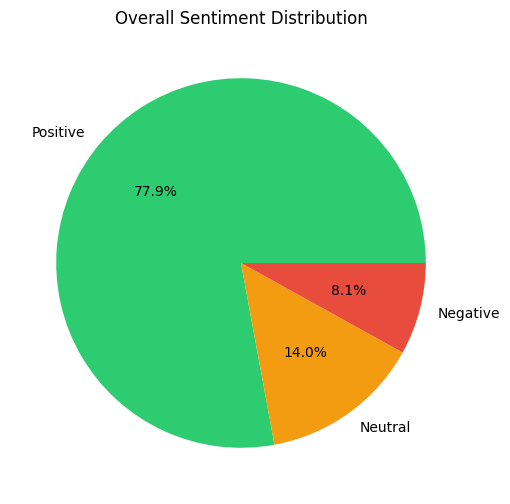

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
df["sentiment_label"].value_counts().plot(
    kind="pie",
    labels=["Positive", "Neutral", "Negative"],
    autopct="%1.1f%%",
    colors=['#2ecc71', '#f39c12', '#e74c3c']
)
plt.title("Overall Sentiment Distribution")
plt.ylabel("")
plt.show()

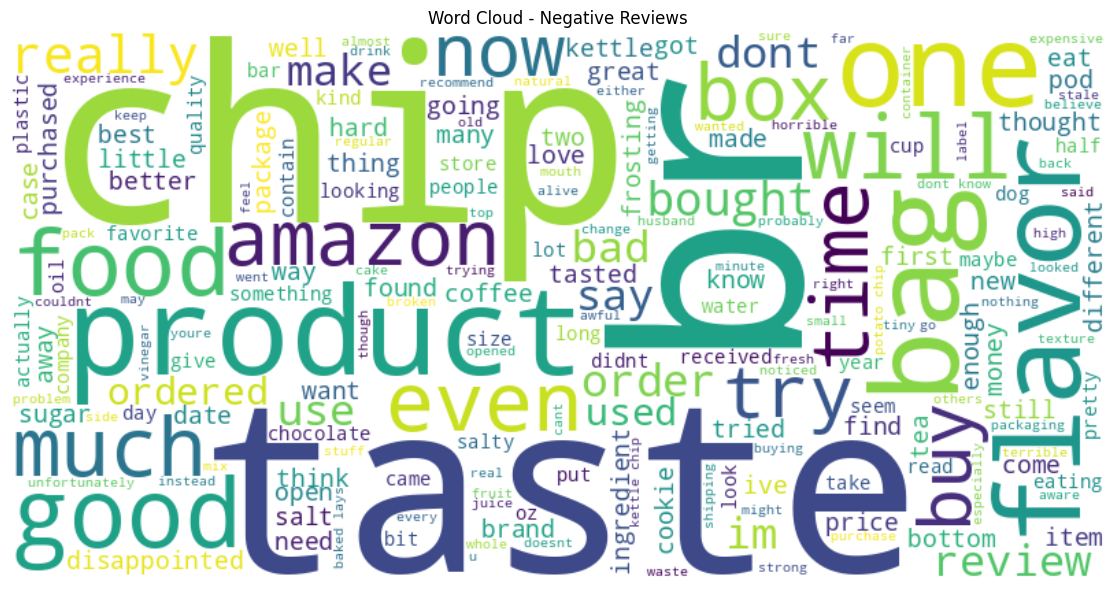

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

negative_text = " ".join(df[df["sentiment_label"] == 0.0]["clean_text"])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.tight_layout()
plt.show()